# RL4EVRP Framework Demo
## Electric Vehicle Routing Problem with Deep Reinforcement Learning

This notebook demonstrates the refactored **rl4evrp** framework using:
- YAML-based configuration management
- Modular encoder/decoder architecture
- A2C training and evaluation
- XAI-ready components

## Setup: Import Framework

In [1]:
import sys
from pathlib import Path

# Add framework to path
framework_path = Path.cwd()
sys.path.insert(0, str(framework_path))

# Import RL4EVRP framework
import rl4evrp as rl

print("✓ RL4EVRP framework imported successfully")

✓ RL4EVRP framework imported successfully


## Load Configuration

In [2]:
# Initialize framework with configs
framework = rl.RL4EVRP()

# Read configurations from YAML files
problem_config = framework.read_yaml('problem')
model_config = framework.read_yaml('model')
env_config = framework.read_yaml('env')

print("Problem Configuration:")
framework.config.print_config()

✓ Device: cpu
✓ Output directory: results_xai
Problem Configuration:

[ENV]
device: cuda
output_directory: results_xai
log_level: INFO
save_checkpoints: True
checkpoint_interval: 100
llm:
  enabled: False
  provider: groq
  model: llama3-8b-8192
  api_key: ${GROQ_API_KEY}
  timeout: 30
reward_tuning:
  charger_visit_penalty: 0.05
  early_return_penalty: 0.3
  service_bonus: 0.2
  completion_bonus: 2.0
  battery_violation_penalty: 1.0
diagnostics:
  track_masked_actions: True
  warn_on_violations: False
reproducibility:
  seed: 42
  deterministic: True

[MODEL]
encoder:
  type: gat
  embed_dim: 128
  n_heads: 8
  n_layers: 3
  ff_dim: 256
  dropout: 0.0
  layer_norm: True
decoder:
  type: cross_attention
  embed_dim: 128
  n_heads: 8
value_head:
  hidden_dim: 64
  activation: gelu
training:
  optimizer: adam
  lr: 0.0003
  epsilon: 1e-05
  weight_decay: 0.0
  scheduler: cosine_annealing
  T_max: 800
  eta_min_factor: 0.1
  grad_clip_norm: 1.0
  gamma: 0.99
  entropy_coefficient: 0.01
  


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Applications/Xcode.app/Contents/Developer/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Applications/Xcode.app/Contents/Developer/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/sdley/Downloads/evrp-framework/.venv/lib/python3.9/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_in

## Build Model

In [3]:
# Build model using builder pattern
model_builder = framework.build()

# Create A2C agent (contains encoder + decoder)
model = model_builder.complete_model()

print(f"Model device: {model.device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

✓ Agent initialized with 487553 parameters
Model device: cpu
Total parameters: 487,553


## Generate Training & Evaluation Data

In [4]:
import numpy as np

# Generate training and evaluation instances
instance_cfg = problem_config['instance_generation']
n_train = instance_cfg.get('train_size', instance_cfg.get('n_train_instances', 200))
n_eval = instance_cfg.get('eval_size', instance_cfg.get('n_eval_instances', 50))
seed_offset = instance_cfg.get('seed_offset', 0)

train_instances = [
    framework.generate_instance(seed=seed_offset + i)
    for i in range(n_train)
]

eval_instances = [
    framework.generate_instance(seed=1000 + seed_offset + i)
    for i in range(n_eval)
]

print(f"✓ Generated {len(train_instances)} training instances")
print(f"✓ Generated {len(eval_instances)} evaluation instances")

# Example instance
demo_inst = train_instances[0]
print(f"\nExample instance:")
print(f"  Nodes: {demo_inst['n_nodes']}")
print(f"  Chargers: {(demo_inst['node_types'] == 2).sum()}")
print(f"  Customers: {(demo_inst['node_types'] == 1).sum()}")

✓ Generated 200 training instances
✓ Generated 50 evaluation instances

Example instance:
  Nodes: 26
  Chargers: 4
  Customers: 21


## Train Agent

In [5]:
from rl4evrp.utils import train_agent

# Train for first seed
seeds = framework.get_seeds()
seed = seeds[0]

print(f"Training with seed: {seed}")

# Set seed
np.random.seed(seed)
import torch
torch.manual_seed(seed)

# Reinitialize model with seed
model = model_builder.complete_model()

# Train for N episodes (use small number for demo)
n_episodes = 50  # Change to 800 for full training

training_results = train_agent(
    model,
    train_instances,
    n_episodes=n_episodes,
    device=str(framework.device),
    save_dir=framework.output_dir / 'checkpoints',
    eval_instances=eval_instances,
    save_interval=10
)

print("✓ Training completed!")

Training with seed: 42
✓ Agent initialized with 487553 parameters
Episode 10: train_reward=-71.563, eval_reward=-36.366, loss=0.4201
Episode 20: train_reward=-37.931, eval_reward=-51.731, loss=0.4192
Episode 30: train_reward=-21.988, eval_reward=-13.546, loss=0.3914
Episode 40: train_reward=-3.410, eval_reward=-7.063, loss=0.1949
Episode 50: train_reward=-3.189, eval_reward=-2.706, loss=0.2644
✓ Training completed!


## Evaluation

In [6]:
from rl4evrp.utils import evaluate_agent

# Evaluate on test set
eval_stats = evaluate_agent(
    model,
    eval_instances,
    device=str(framework.device),
    greedy=True,
    n_eval=20
)

print("\nEvaluation Results:")
print(f"  Mean Reward: {eval_stats['mean_reward']:.3f} ± {eval_stats['std_reward']:.3f}")
print(f"  Mean Distance: {eval_stats['mean_distance']:.3f} ± {eval_stats['std_distance']:.3f}")


Evaluation Results:
  Mean Reward: -3.215 ± 1.131
  Mean Distance: 9.676 ± 1.454


## Route Visualization Example

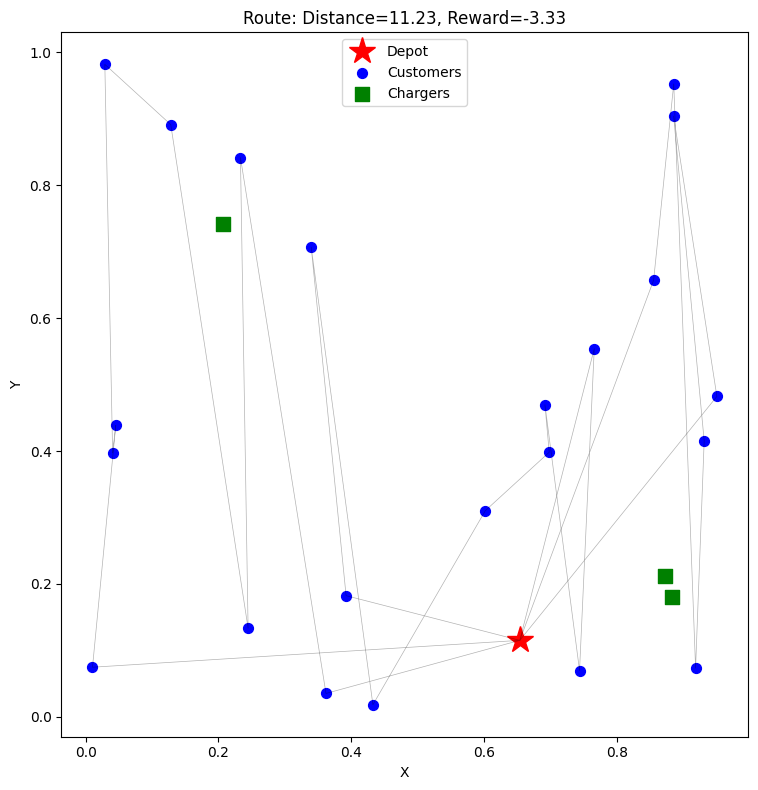

Route: [0, 16, 24, 3, 10, 22, 17, 4, 12, 0, 6, 11, 20, 25, 18, 21, 7, 14, 0, 13, 8, 23, 9, 15, 1, 0]
Battery violations: 0
Charger visits: 0


In [7]:
import matplotlib.pyplot as plt
from rl4evrp.utils import run_episode

# Run episode and collect route
test_inst = eval_instances[0]
reward, route, dist, info, _, _, env = run_episode(
    model,
    test_inst,
    device=str(framework.device),
    greedy=True
)

# Plot route
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Plot coordinates
coords = test_inst['coords']
types = test_inst['node_types']

# Depot
ax.plot(coords[0, 0], coords[0, 1], 'r*', markersize=20, label='Depot')

# Customers
customer_mask = types == 1
ax.scatter(coords[customer_mask, 0], coords[customer_mask, 1], c='blue', s=50, label='Customers')

# Chargers
charger_mask = types == 2
if charger_mask.any():
    ax.scatter(coords[charger_mask, 0], coords[charger_mask, 1], c='green', s=100, marker='s', label='Chargers')

# Route
route_coords = coords[route]
ax.plot(route_coords[:, 0], route_coords[:, 1], 'k-', alpha=0.3, linewidth=0.5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title(f'Route: Distance={dist:.2f}, Reward={reward:.2f}')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f"Route: {route}")
print(f"Battery violations: {info['batt_violations']}")
print(f"Charger visits: {info['charger_visits']}")

## Training Diagnostics

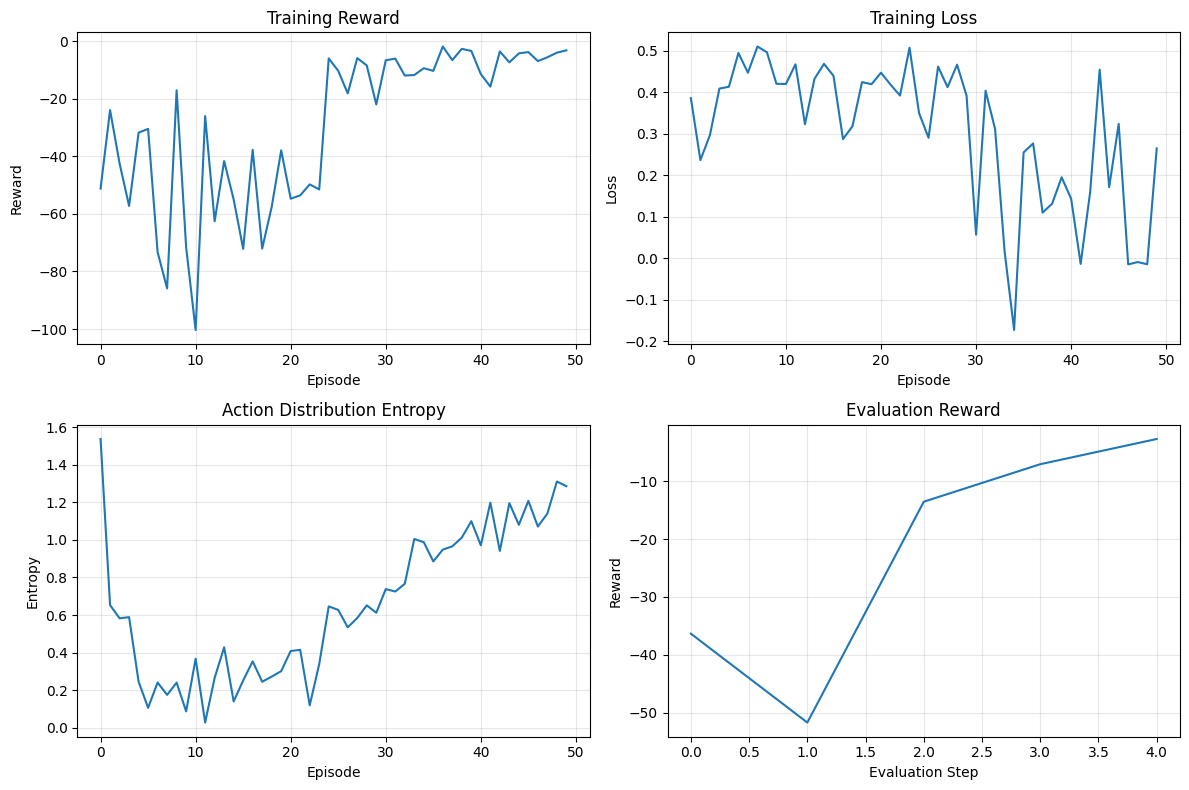

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Training rewards
axes[0, 0].plot(training_results['train_rewards'])
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Reward')
axes[0, 0].set_title('Training Reward')
axes[0, 0].grid(True, alpha=0.3)

# Training loss
axes[0, 1].plot(training_results['losses'])
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Training Loss')
axes[0, 1].grid(True, alpha=0.3)

# Entropy
axes[1, 0].plot(training_results['entropies'])
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Entropy')
axes[1, 0].set_title('Action Distribution Entropy')
axes[1, 0].grid(True, alpha=0.3)

# Evaluation rewards
if training_results['eval_rewards']:
    axes[1, 1].plot(training_results['eval_rewards'])
    axes[1, 1].set_xlabel('Evaluation Step')
    axes[1, 1].set_ylabel('Reward')
    axes[1, 1].set_title('Evaluation Reward')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save Model Checkpoint

In [9]:
import torch

# Save model
checkpoint_path = framework.output_dir / 'final_model.pt'
torch.save(model.state_dict(), checkpoint_path)

print(f"✓ Model saved to {checkpoint_path}")

# Also save training config
import json
config_save_path = framework.output_dir / 'training_config.json'
json.dump({
    'problem': problem_config,
    'model': model_config,
    'n_episodes': n_episodes,
    'seed': seed
}, open(config_save_path, 'w'), indent=2, default=str)

print(f"✓ Config saved to {config_save_path}")

✓ Model saved to results_xai/final_model.pt
✓ Config saved to results_xai/training_config.json
